In [1]:
import os
from dotenv import load_dotenv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

paysim = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "ealaxi/paysim1",
    "PS_20174392719_1491204439457_log.csv"
)

/Users/ngocduy/PROJECTS/smart-banking-system/ml/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
paysim.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
paysim.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


In [5]:
paysim.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [6]:
paysim.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


/var/folders/gg/6wc4xmjd1pqd5srwvxfkp9_c0000gn/T/ipykernel_85114/292799447.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/var/folders/gg/6wc4xmjd1pqd5srwvxfkp9_c0000gn/T/ipykernel_85114/292799447.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=paysim["isFlaggedFraud"].map({0: "Not Flagged", 1: "Flagged"}),


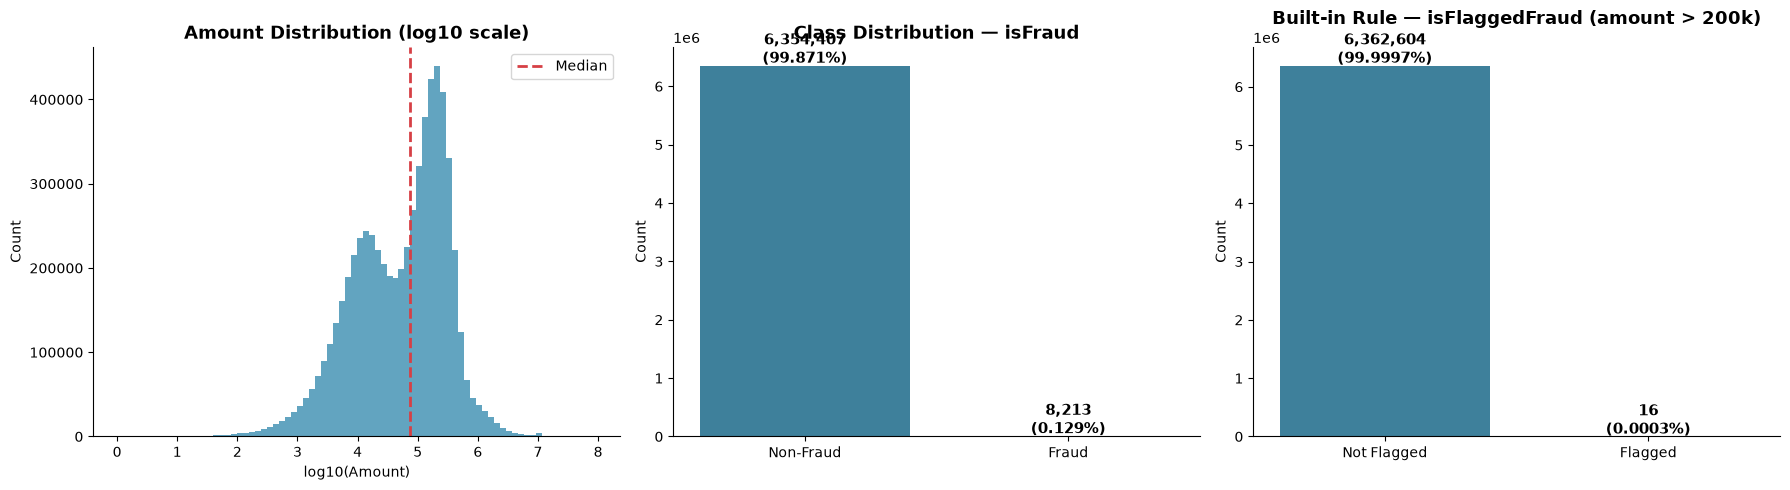

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Panel 1: Amount Distribution (log scale) ---
sns.histplot(np.log10(paysim["amount"] + 1), bins=80, color="#2E86AB", edgecolor=None, ax=axes[0])
axes[0].set_title("Amount Distribution (log10 scale)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("log10(Amount)")
axes[0].axvline(np.log10(paysim["amount"].median()), color="#D64045", linestyle="--", linewidth=2, label="Median")
axes[0].legend()

# --- Panel 2: isFraud (Class Imbalance) ---
sns.countplot(
    x=paysim["isFraud"].map({0: "Non-Fraud", 1: "Fraud"}),
    palette={"Non-Fraud": "#2E86AB", "Fraud": "#D64045"},
    ax=axes[1])
axes[1].set_title("Class Distribution — isFraud", fontsize=13, fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("Count")
# Add % labels
total = len(paysim)
for p in axes[1].patches:
    pct = p.get_height() / total * 100
    axes[1].text(
        p.get_x() + p.get_width()/2, p.get_height() + 50000,
        f"{p.get_height():,.0f}\n({pct:.3f}%)",
        ha="center", fontsize=11, fontweight="bold")

# --- Panel 3: isFlaggedFraud ---
sns.countplot(x=paysim["isFlaggedFraud"].map({0: "Not Flagged", 1: "Flagged"}),
    palette={"Not Flagged": "#2E86AB", "Flagged": "#F2A900"},
    ax=axes[2])
axes[2].set_title("Built-in Rule — isFlaggedFraud (amount > 200k)", fontsize=13, fontweight="bold")
axes[2].set_xlabel("")
axes[2].set_ylabel("Count")
for p in axes[2].patches:
    pct = p.get_height() / total * 100
    axes[2].text(p.get_x() + p.get_width()/2, p.get_height() + 50000,
        f"{p.get_height():,.0f}\n({pct:.4f}%)",
        ha="center", fontsize=11, fontweight="bold")

sns.despine()
plt.tight_layout()
plt.show()

Total rows matching: 2,317,266 (36.42%)

=== Breakdown by Transaction Type ===
            count  pct_of_total  fraud_count  fraud_rate
type                                                    
PAYMENT   2151495     33.814608            0    0.000000
CASH_IN    160005      2.514766            0    0.000000
TRANSFER     4158      0.065350         4052   97.450697
CASH_OUT     1608      0.025273            8    0.497512


/var/folders/gg/6wc4xmjd1pqd5srwvxfkp9_c0000gn/T/ipykernel_85114/653395835.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


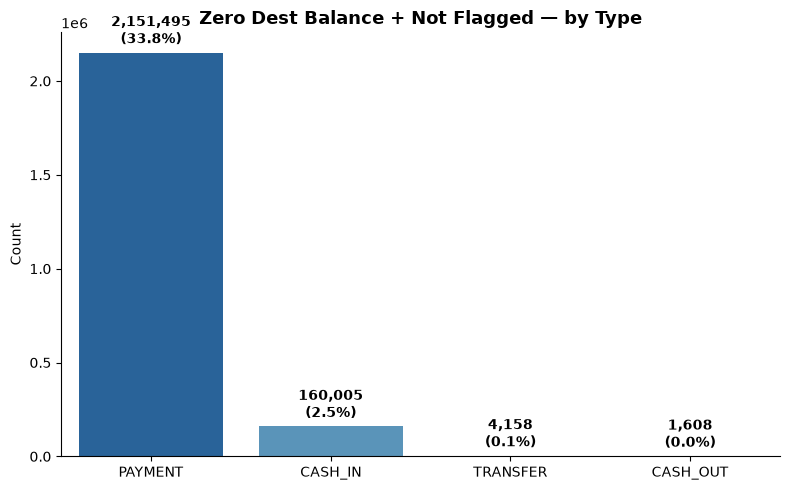

In [11]:
mask = (paysim["isFlaggedFraud"] == 0) & (paysim["oldbalanceDest"] == 0) & (paysim["newbalanceDest"] == 0)

zero_dest_not_flagged = paysim[mask]

print(f"Total rows matching: {len(zero_dest_not_flagged):,} "
      f"({len(zero_dest_not_flagged) / len(paysim) * 100:.2f}%)")

print("\n=== Breakdown by Transaction Type ===")
breakdown = zero_dest_not_flagged.groupby("type").agg(
    count=("type", "count"),
    pct_of_total=("type", lambda x: len(x) / len(paysim) * 100),
    fraud_count=("isFraud", "sum"),
    fraud_rate=("isFraud", "mean"),
).sort_values("count", ascending=False)

breakdown["fraud_rate"] = breakdown["fraud_rate"] * 100
print(breakdown)

# Visualize
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    x=breakdown.index,
    y=breakdown["count"],
    palette="Blues_r",
    ax=ax,
)
for i, (count, pct) in enumerate(zip(breakdown["count"], breakdown["pct_of_total"])):
    ax.text(i, count + 50000, f"{count:,}\n({pct:.1f}%)", ha="center", fontsize=10, fontweight="bold")
ax.set_title("Zero Dest Balance + Not Flagged — by Type", fontsize=13, fontweight="bold")
ax.set_ylabel("Count")
ax.set_xlabel("")
sns.despine()
plt.tight_layout()
plt.show()

<Axes: xlabel='isFraud', ylabel='amount'>

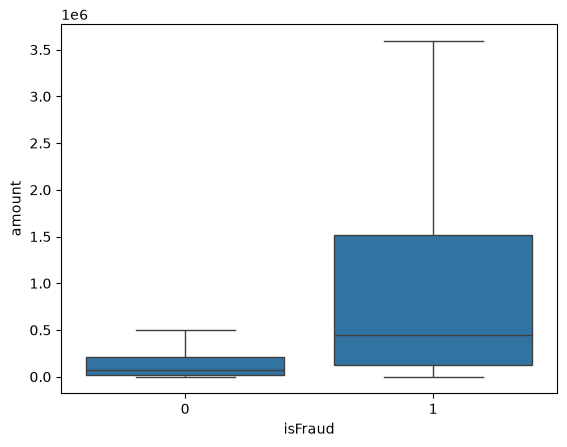

In [12]:
sns.boxplot(x="isFraud", y="amount", data=paysim, showfliers=False)

<Axes: >

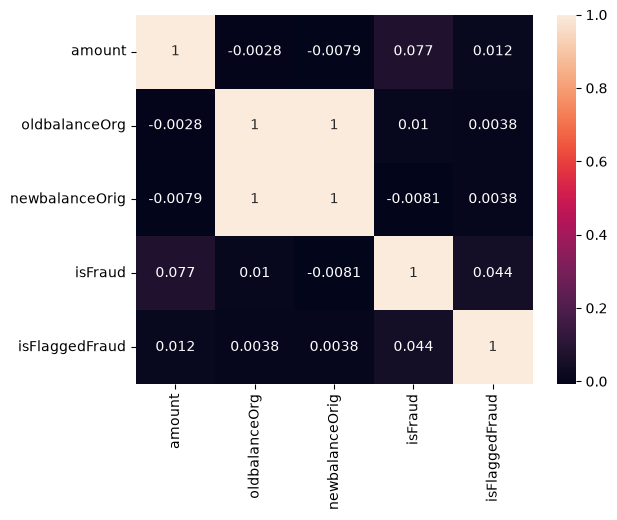

In [13]:
sns.heatmap(paysim[["amount", "oldbalanceOrg", "newbalanceOrig", "isFraud", "isFlaggedFraud"]].corr(), annot=True)

/var/folders/gg/6wc4xmjd1pqd5srwvxfkp9_c0000gn/T/ipykernel_85114/1037919510.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


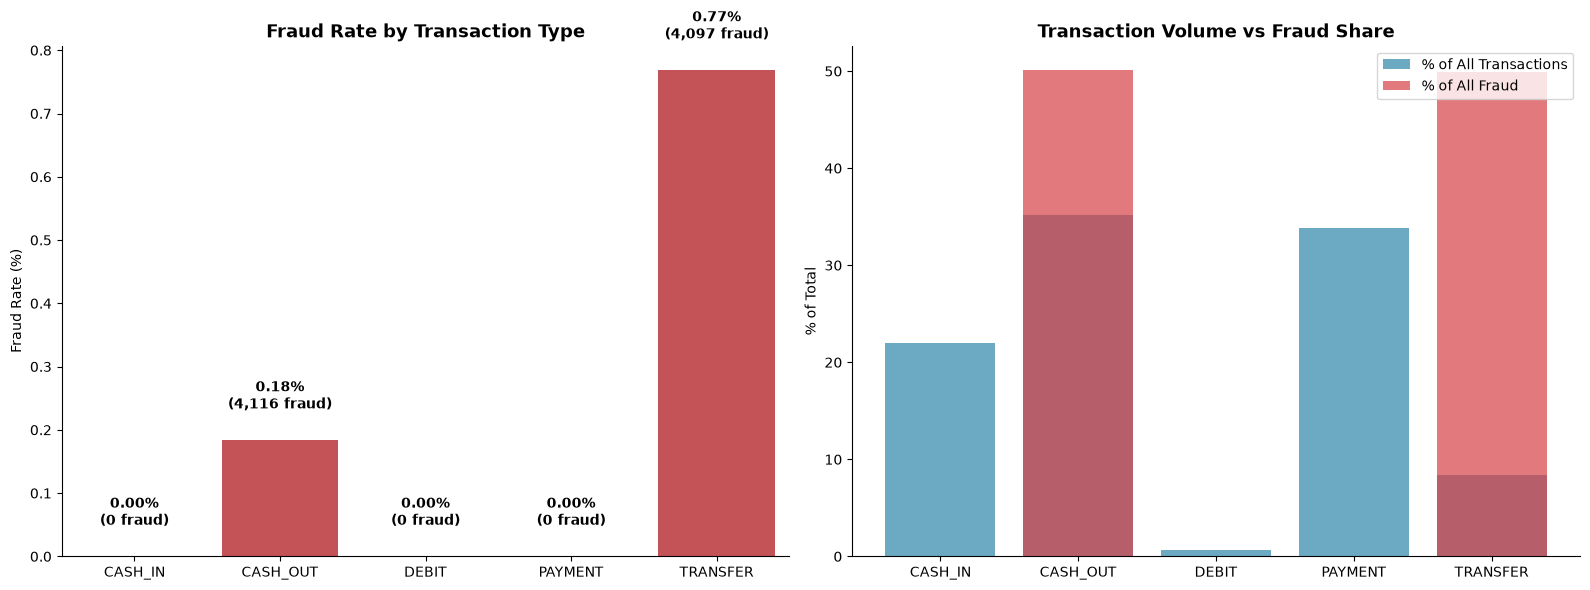


🔴 Fraud ONLY occurs in: ['CASH_OUT', 'TRANSFER']
🟢 Zero fraud in: ['CASH_IN', 'DEBIT', 'PAYMENT']
→ This means 'type' alone can eliminate 56.5% of transactions from suspicion.


In [ ]:
# ============================================================
# Transaction Type vs Fraud
# ============================================================

type_stats = paysim.groupby("type").agg(
    total_txns=("isFraud", "count"),
    fraud_txns=("isFraud", "sum"),
    fraud_rate=("isFraud", "mean"),
    avg_amount=("amount", "mean"),
).reset_index()

type_stats["fraud_rate_pct"] = type_stats["fraud_rate"] * 100
type_stats["pct_of_all_txns"] = type_stats["total_txns"] / len(paysim) * 100
type_stats["pct_of_all_fraud"] = type_stats["fraud_txns"] / paysim["isFraud"].sum() * 100

print(type_stats[["type", "total_txns", "fraud_txns", "fraud_rate_pct", "pct_of_all_fraud"]].to_string(index=False))

# --- Visual ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    x=type_stats["type"], y=type_stats["fraud_rate_pct"],
    palette=["#D64045" if r > 0 else "#2E86AB" for r in type_stats["fraud_rate_pct"]],
    ax=axes[0],
)
for i, (rate, count) in enumerate(zip(type_stats["fraud_rate_pct"], type_stats["fraud_txns"])):
    axes[0].text(i, rate + 0.05, f"{rate:.2f}%\n({int(count):,})", ha="center", fontsize=10, fontweight="bold")
axes[0].set_title("Fraud Rate by Transaction Type", fontweight="bold")
axes[0].set_ylabel("Fraud Rate (%)")

x = type_stats["type"]
axes[1].bar(x, type_stats["pct_of_all_txns"], color="#2E86AB", alpha=0.7, label="% of All Transactions")
axes[1].bar(x, type_stats["pct_of_all_fraud"], color="#D64045", alpha=0.7, label="% of All Fraud")
axes[1].set_title("Volume vs Fraud Share", fontweight="bold")
axes[1].set_ylabel("% of Total")
axes[1].legend()

sns.despine()
plt.tight_layout()
plt.show()

### Key Findings: Transaction Type

- **Fraud occurs ONLY in `TRANSFER` (0.77%) and `CASH_OUT` (0.18%)**. CASH_IN, PAYMENT, and DEBIT have zero fraud.
- Filtering by type alone eliminates **56.5% of transactions** with zero false negatives.
- TRANSFER has 4x the fraud rate of CASH_OUT despite 1/4 the volume — it's the riskiest type.
- TRANSFER avg amount ($910k) is 5x CASH_OUT ($176k) — fraudsters move large sums via transfers.

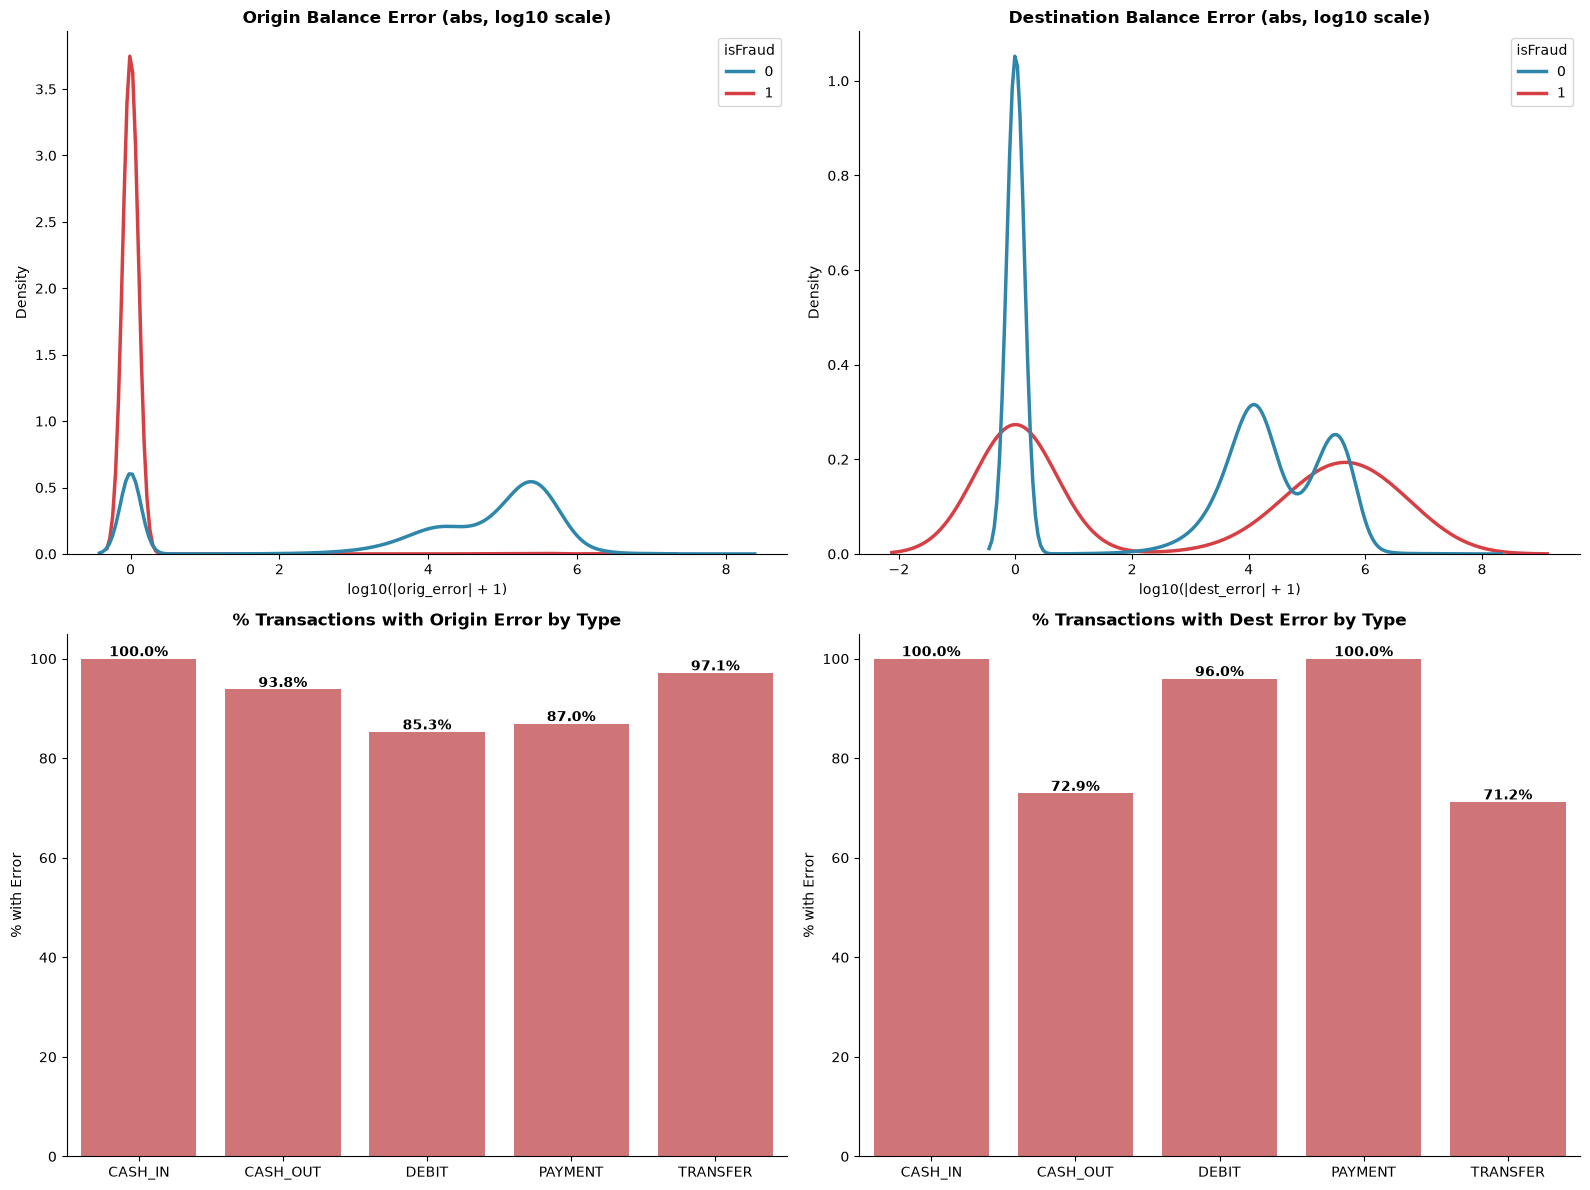


🔴 Fraud origin error rate: 0.8% vs Legit: 93.2%
🔴 Fraud dest error rate:   73.6% vs Legit: 88.1%
→ Balance errors are a strong fraud indicator in PaySim.


In [ ]:
# ============================================================
# Balance Delta Errors
# ============================================================
# Legit: oldbalanceOrg - newbalanceOrig == amount, newbalanceDest - oldbalanceDest == amount
# Fraudsters often leave accounting errors.

paysim["orig_error"] = paysim["oldbalanceOrg"] - paysim["newbalanceOrig"] - paysim["amount"]
paysim["dest_error"] = paysim["newbalanceDest"] - paysim["oldbalanceDest"] - paysim["amount"]
paysim["has_orig_error"] = (paysim["orig_error"] != 0).astype(int)
paysim["has_dest_error"] = (paysim["dest_error"] != 0).astype(int)

# --- Print summary ---
print("=== Error Rates: Fraud vs Legit ===")
print(f"Origin error — Fraud: {paysim[paysim['isFraud']==1]['has_orig_error'].mean()*100:.1f}%  |  Legit: {paysim[paysim['isFraud']==0]['has_orig_error'].mean()*100:.1f}%")
print(f"Dest error   — Fraud: {paysim[paysim['isFraud']==1]['has_dest_error'].mean()*100:.1f}%  |  Legit: {paysim[paysim['isFraud']==0]['has_dest_error'].mean()*100:.1f}%")

print("\n=== Dest Error by Type (Fraud only) ===")
dest_by_type = paysim[paysim["isFraud"]==1].groupby("type")["has_dest_error"].mean() * 100
print(dest_by_type.to_string())

# --- Visual ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.kdeplot(
    data=paysim, x=np.log10(paysim["orig_error"].abs() + 1), hue="isFraud",
    palette={0: "#2E86AB", 1: "#D64045"}, linewidth=2.5,
    common_norm=False, bw_adjust=1.5, ax=axes[0, 0],
)
axes[0, 0].set_title("Origin Balance Error (abs, log10)", fontweight="bold")

sns.kdeplot(
    data=paysim, x=np.log10(paysim["dest_error"].abs() + 1), hue="isFraud",
    palette={0: "#2E86AB", 1: "#D64045"}, linewidth=2.5,
    common_norm=False, bw_adjust=1.5, ax=axes[0, 1],
)
axes[0, 1].set_title("Dest Balance Error (abs, log10)", fontweight="bold")

orig_pct = paysim.groupby("type")["has_orig_error"].mean() * 100
sns.barplot(x=orig_pct.index, y=orig_pct.values, color="#D64045", alpha=0.8, ax=axes[1, 0])
axes[1, 0].set_title("% with Origin Error by Type", fontweight="bold")
for i, v in enumerate(orig_pct.values):
    axes[1, 0].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=10, fontweight="bold")

dest_pct = paysim.groupby("type")["has_dest_error"].mean() * 100
sns.barplot(x=dest_pct.index, y=dest_pct.values, color="#D64045", alpha=0.8, ax=axes[1, 1])
axes[1, 1].set_title("% with Dest Error by Type", fontweight="bold")
for i, v in enumerate(dest_pct.values):
    axes[1, 1].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=10, fontweight="bold")

sns.despine()
plt.tight_layout()
plt.show()

### Key Findings: Balance Delta Errors

- **Origin error is inverted**: 93.2% of legit txns have origin errors vs only 0.8% of fraud. `has_orig_error == 0` is a fraud indicator.
- **TRANSFER fraud = 100% dest error**: The money never arrives — both `oldbalanceDest` and `newbalanceDest` stay at 0.
- **CASH_OUT fraud = 47% dest error**: About half the time, fraudsters don't update the destination balance correctly.
- These are among the strongest individual features in PaySim.

=== Step Overview ===
Total steps: 743
Step range: 1 to 743

Top 5 steps by fraud rate:
 step  total_txns  fraud_txns  fraud_rate_pct
   28           4           4           100.0
   29           4           4           100.0
   30           8           8           100.0
   31          12          12           100.0
   32          12          12           100.0

Top 5 steps by fraud count:
 step  total_txns  fraud_txns  fraud_rate_pct
  212       34047          40        0.117485
  523          30          30      100.000000
  249       23209          28        0.120643
  387          28          28      100.000000
  425          28          28      100.000000


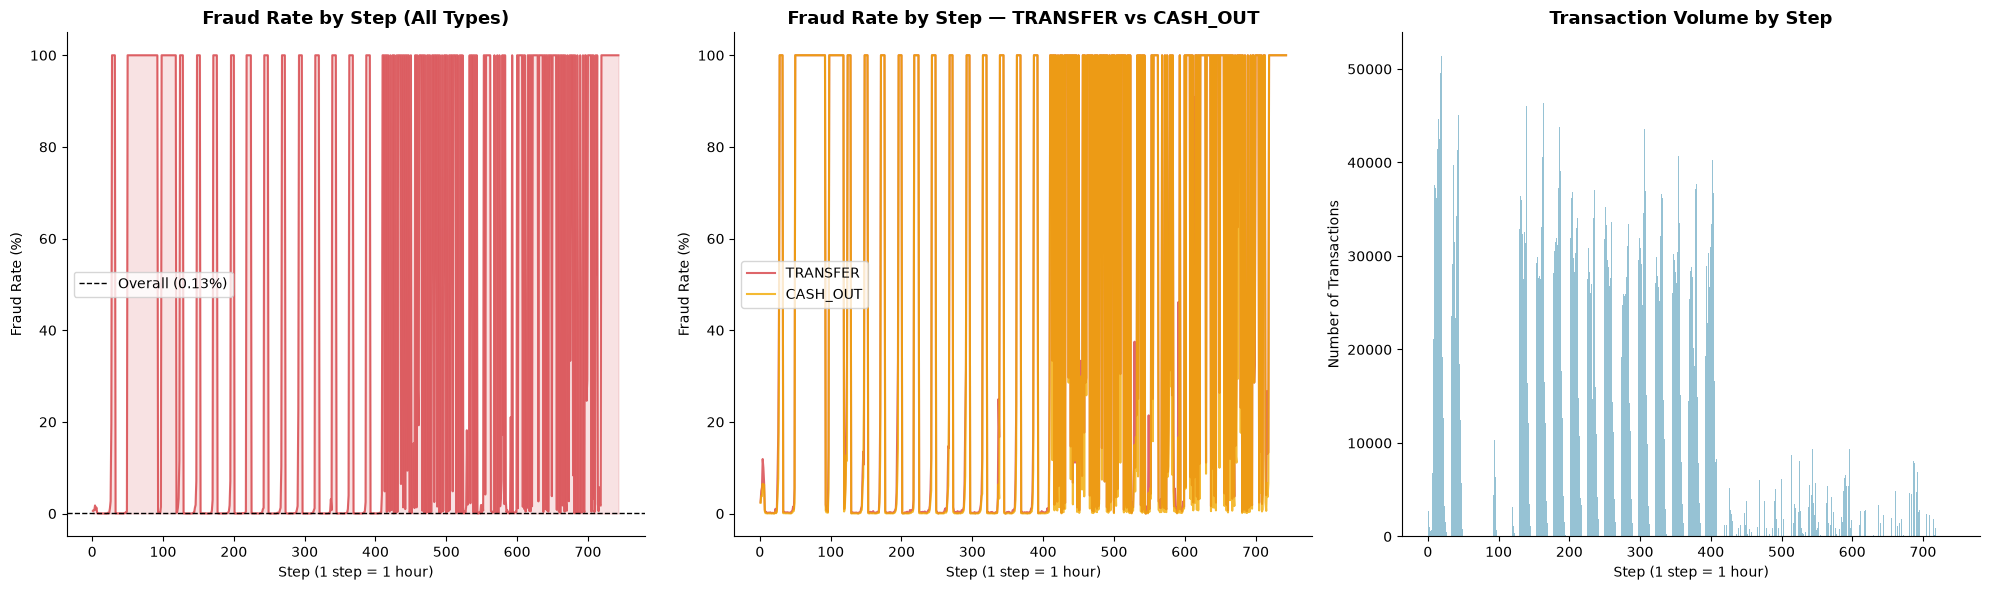


🔴 Top 10 steps account for 286 fraud txns (3.5% of all fraud)
   These 10 steps represent 1.8% of all transactions

=== Simulation Half Comparison ===
First half (step ≤ 239): fraud rate = 0.085%
Second half (step > 239): fraud rate = 0.173%


In [ ]:
# ============================================================
# Time Patterns — Fraud Rate by Step (1 step = 1 hour)
# ============================================================

step_stats = paysim.groupby("step").agg(
    total_txns=("isFraud", "count"),
    fraud_txns=("isFraud", "sum"),
    fraud_rate=("isFraud", "mean"),
).reset_index()
step_stats["fraud_rate_pct"] = step_stats["fraud_rate"] * 100

fraud_types_mask = paysim["type"].isin(["TRANSFER", "CASH_OUT"])
step_type_stats = paysim[fraud_types_mask].groupby(["step", "type"]).agg(
    total_txns=("isFraud", "count"),
    fraud_txns=("isFraud", "sum"),
    fraud_rate=("isFraud", "mean"),
).reset_index()
step_type_stats["fraud_rate_pct"] = step_type_stats["fraud_rate"] * 100

# --- Print summary ---
midpoint = paysim["step"].median()
first_half = paysim[paysim["step"] <= midpoint]["isFraud"].mean() * 100
second_half = paysim[paysim["step"] > midpoint]["isFraud"].mean() * 100
print(f"First half (step ≤ {midpoint:.0f}): {first_half:.3f}%  |  Second half: {second_half:.3f}%  |  Ratio: {second_half/first_half:.1f}x")

# --- Visual ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].plot(step_stats["step"], step_stats["fraud_rate_pct"], color="#D64045", linewidth=1.5, alpha=0.8)
axes[0].fill_between(step_stats["step"], step_stats["fraud_rate_pct"], alpha=0.15, color="#D64045")
axes[0].axhline(y=paysim["isFraud"].mean() * 100, color="black", linestyle="--", linewidth=1, label=f"Overall ({paysim['isFraud'].mean()*100:.2f}%)")
axes[0].set_title("Fraud Rate by Step (All Types)", fontweight="bold")
axes[0].set_xlabel("Step (1 step = 1 hour)")
axes[0].set_ylabel("Fraud Rate (%)")
axes[0].legend()

for t, color in [("TRANSFER", "#D64045"), ("CASH_OUT", "#F2A900")]:
    subset = step_type_stats[step_type_stats["type"] == t]
    axes[1].plot(subset["step"], subset["fraud_rate_pct"], color=color, linewidth=1.5, label=t, alpha=0.8)
axes[1].set_title("Fraud Rate by Step — TRANSFER vs CASH_OUT", fontweight="bold")
axes[1].set_xlabel("Step (1 step = 1 hour)")
axes[1].set_ylabel("Fraud Rate (%)")
axes[1].legend()

axes[2].bar(step_stats["step"], step_stats["total_txns"], color="#2E86AB", alpha=0.5, width=1.0)
axes[2].set_title("Transaction Volume by Step", fontweight="bold")
axes[2].set_xlabel("Step (1 step = 1 hour)")
axes[2].set_ylabel("Number of Transactions")

sns.despine()
plt.tight_layout()
plt.show()

### Key Findings: Time Patterns (Step)

- Fraud is **not concentrated** in specific hours — the top 10 steps account for only 3.5% of all fraud.
- **Second half has 2x the fraud rate** (0.173% vs 0.085%) — fraud increases as simulation progresses.
- 100% fraud steps (28-32, 523) are tiny bursts (4-30 txns) — likely synthetic injection artifacts.
- TRANSFER fraud rate is consistently higher than CASH_OUT across all steps.

=== Day Overview ===
Total days: 31
Day range: 1 to 31
Avg txns/day: 205,246
Avg fraud/day: 264.9

Top 5 days by fraud rate:
 day  total_txns  fraud_txns  fraud_rate_pct
  31         272         272      100.000000
   3        1070         310       28.971963
  27        8578         280        3.264164
   5        9789         252        2.574318
  30       11287         268        2.374413

Top 5 days by fraud count:
 day  total_txns  fraud_txns  fraud_rate_pct
  17      425766         320        0.075159
   3        1070         310       28.971963
   2      455238         309        0.067877
  12      349776         298        0.085197
  10      392945         282        0.071766

=== Fraud by Day of Week ===
label  total_txns  fraud_txns  fraud_rate_pct
  Mon     1533501        1315        0.085751
  Tue     1311050        1300        0.099157
  Wed      852762        1464        0.171677
  Thu      524951        1032        0.196590
  Fri      384750        1078        0.280182
 

/var/folders/gg/6wc4xmjd1pqd5srwvxfkp9_c0000gn/T/ipykernel_85114/3453283723.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dow_stats["label"], y=dow_stats["fraud_rate_pct"],


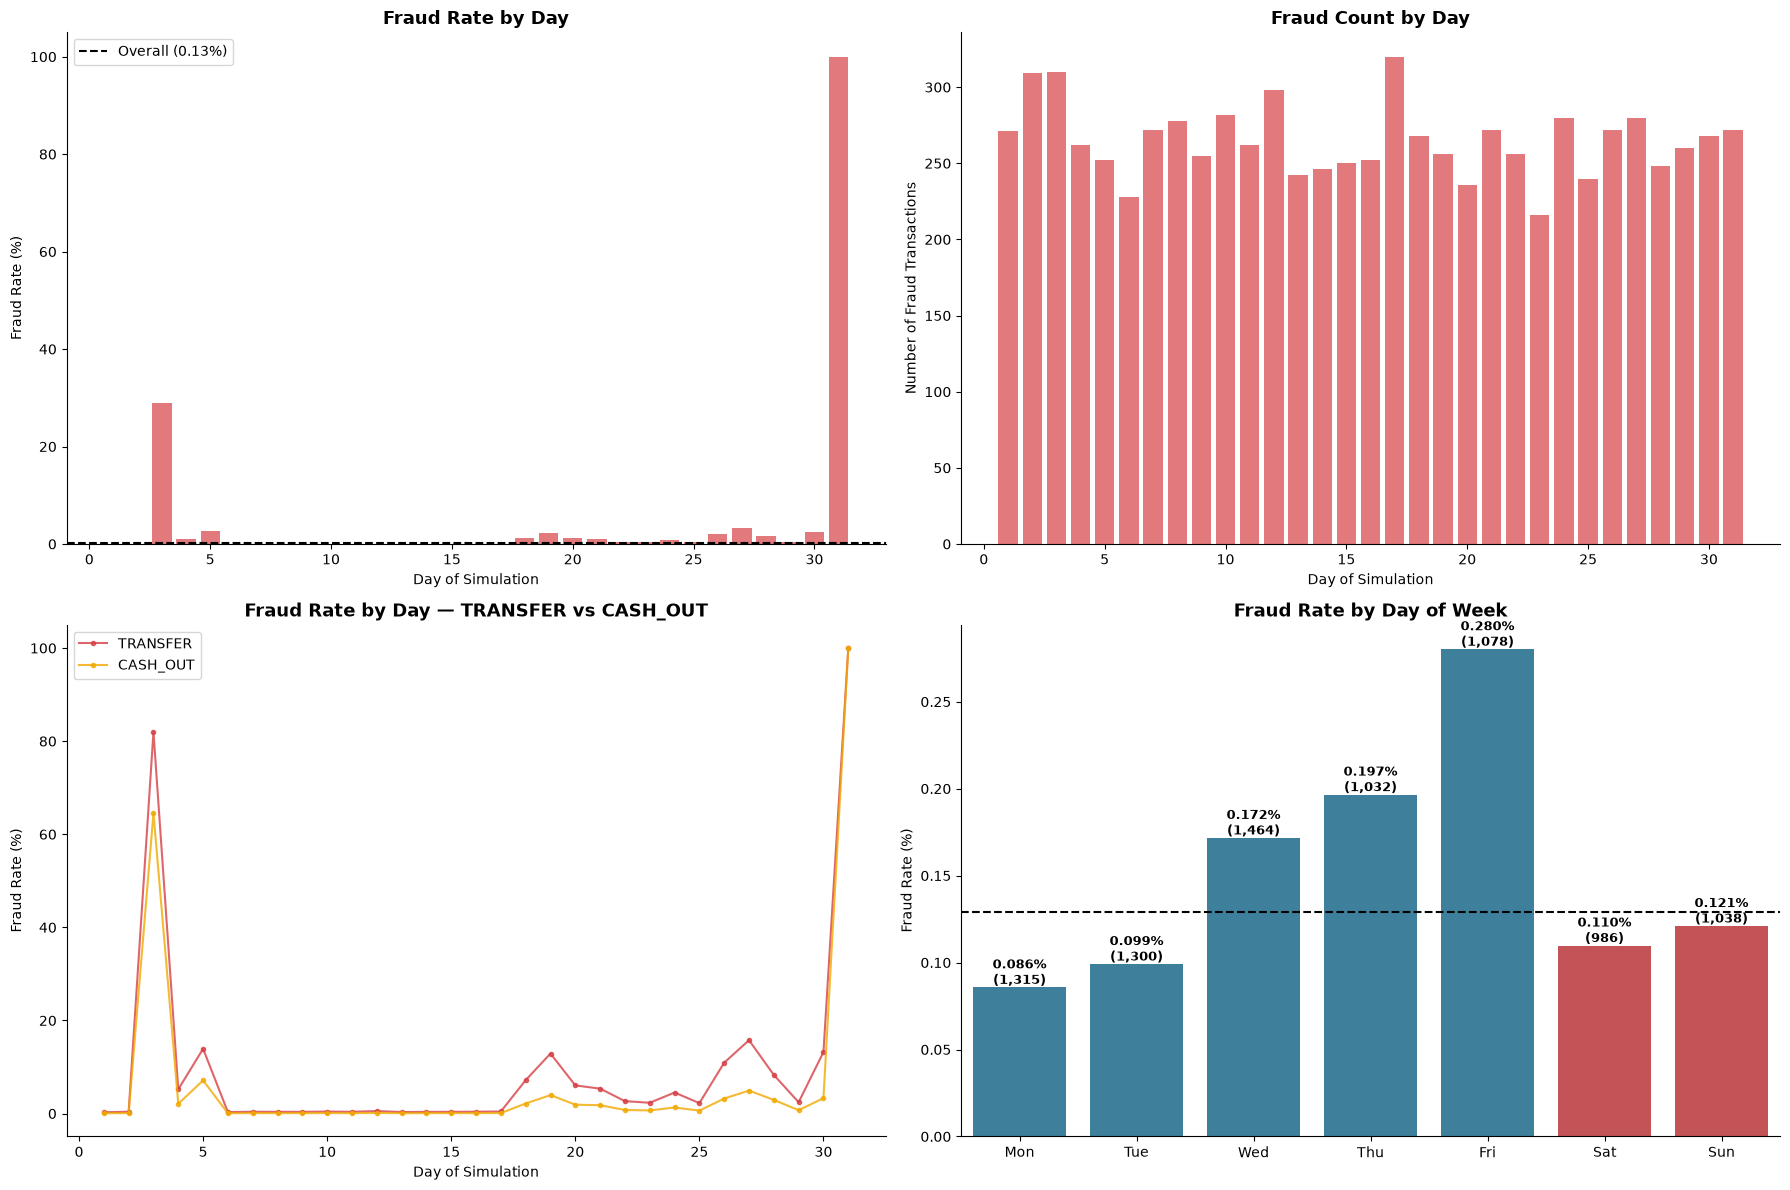


🔴 Highest fraud day: Day 31 (100.00%)
🔴 Highest fraud count day: Day 17 (320 fraud txns)

📅 Weekday fraud rate: 0.134%
📅 Weekend fraud rate: 0.115%
   Ratio: 0.86x


In [ ]:
# ============================================================
# Fraud by Day — Step → Day (24 steps = 1 day)
# ============================================================

paysim["day"] = (paysim["step"] - 1) // 24 + 1
paysim["day_of_week"] = (paysim["day"] - 1) % 7  # 0=Mon ... 6=Sun
dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

day_stats = paysim.groupby("day").agg(
    total_txns=("isFraud", "count"),
    fraud_txns=("isFraud", "sum"),
    fraud_rate=("isFraud", "mean"),
).reset_index()
day_stats["fraud_rate_pct"] = day_stats["fraud_rate"] * 100

fraud_mask = paysim["type"].isin(["TRANSFER", "CASH_OUT"])
day_type_stats = paysim[fraud_mask].groupby(["day", "type"]).agg(
    total_txns=("isFraud", "count"),
    fraud_txns=("isFraud", "sum"),
    fraud_rate=("isFraud", "mean"),
).reset_index()
day_type_stats["fraud_rate_pct"] = day_type_stats["fraud_rate"] * 100

dow_stats = paysim.groupby("day_of_week").agg(
    total_txns=("isFraud", "count"),
    fraud_txns=("isFraud", "sum"),
    fraud_rate=("isFraud", "mean"),
).reset_index()
dow_stats["fraud_rate_pct"] = dow_stats["fraud_rate"] * 100
dow_stats["label"] = dow_stats["day_of_week"].apply(lambda x: dow_labels[x])

# --- Print summary ---
print("=== Fraud Rate by Day of Week ===")
print(dow_stats[["label", "fraud_rate_pct", "fraud_txns"]].to_string(index=False))

weekday_rate = paysim[paysim["day_of_week"].isin([0,1,2,3,4])]["isFraud"].mean() * 100
weekend_rate = paysim[paysim["day_of_week"].isin([5,6])]["isFraud"].mean() * 100
print(f"\nWeekday: {weekday_rate:.3f}%  |  Weekend: {weekend_rate:.3f}%  |  Fri/Mon ratio: {dow_stats.loc[4,'fraud_rate_pct']/dow_stats.loc[0,'fraud_rate_pct']:.1f}x")

# --- Visual ---
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

axes[0, 0].bar(day_stats["day"], day_stats["fraud_rate_pct"], color="#D64045", alpha=0.7, width=0.8)
axes[0, 0].axhline(y=paysim["isFraud"].mean() * 100, color="black", linestyle="--", linewidth=1.5, label=f"Overall ({paysim['isFraud'].mean()*100:.2f}%)")
axes[0, 0].set_title("Fraud Rate by Day", fontweight="bold")
axes[0, 0].set_xlabel("Day of Simulation")
axes[0, 0].set_ylabel("Fraud Rate (%)")
axes[0, 0].legend()

axes[0, 1].bar(day_stats["day"], day_stats["fraud_txns"], color="#D64045", alpha=0.7, width=0.8)
axes[0, 1].set_title("Fraud Count by Day", fontweight="bold")
axes[0, 1].set_xlabel("Day of Simulation")
axes[0, 1].set_ylabel("Fraud Transactions")

for t, color in [("TRANSFER", "#D64045"), ("CASH_OUT", "#F2A900")]:
    subset = day_type_stats[day_type_stats["type"] == t]
    axes[1, 0].plot(subset["day"], subset["fraud_rate_pct"], color=color, linewidth=1.5, marker="o", markersize=3, label=t, alpha=0.8)
axes[1, 0].set_title("Fraud Rate by Day — TRANSFER vs CASH_OUT", fontweight="bold")
axes[1, 0].set_xlabel("Day of Simulation")
axes[1, 0].set_ylabel("Fraud Rate (%)")
axes[1, 0].legend()

sns.barplot(x=dow_stats["label"], y=dow_stats["fraud_rate_pct"],
            palette=["#2E86AB" if i < 5 else "#D64045" for i in range(7)], ax=axes[1, 1])
axes[1, 1].axhline(y=paysim["isFraud"].mean() * 100, color="black", linestyle="--", linewidth=1.5)
axes[1, 1].set_title("Fraud Rate by Day of Week", fontweight="bold")
axes[1, 1].set_ylabel("Fraud Rate (%)")
for i, (rate, count) in enumerate(zip(dow_stats["fraud_rate_pct"], dow_stats["fraud_txns"])):
    axes[1, 1].text(i, rate + 0.002, f"{rate:.3f}%\n({int(count):,})", ha="center", fontsize=9, fontweight="bold")

sns.despine()
plt.tight_layout()
plt.show()

### Key Findings: Fraud by Day

- **Fraud rate climbs through the workweek**: Mon (0.086%) → Fri (0.280%) — a **3.3x increase**.
- Weekends drop back to ~0.11%, creating a clear "midweek hump" pattern.
- Day 3 (28.97% fraud) and Day 31 (100% fraud) are synthetic injection artifacts — not real patterns.
- High-volume days ≠ high fraud rate days. Day 17 has the most fraud (320) but only 0.075% rate.
- `day_of_week` is a solid feature; `is_weekend` alone is weak (0.115% vs 0.134% weekday).